In [1]:
# 1) ensure Python can see your project root
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("→ Added to sys.path:", project_root)
print("→ cwd is:", os.getcwd())

from environments.auv_env    import AUVEnv
from agents.auv_dqn_agent    import AuvDQNAgent
from agents.dqn_agent      import train_dqn
from utils.grid_utils     import plot_rewards, evaluate_agent
from utils.graphics_utils import record_headless

→ Added to sys.path: /Users/eirikvarnes/code/auv-rl-project
→ cwd is: /Users/eirikvarnes/code/auv-rl-project/notebooks
pygame 2.6.1 (SDL 2.28.4, Python 3.11.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
env = AUVEnv(
    grid_size=(200,200),
    resolution=0.1,
    docks=1,
    dock_radius=1.0,
    dock_reward=20.0,
    n_beams=12,
    start_mode='random',
    use_history=True,
    history_length=6,
)

# 2) Create agent
agent = AuvDQNAgent(env,
                          hidden_dims=[64,64],
                          lr=1e-3,
                          gamma=0.95,
                          epsilon_start=1.0,
                          epsilon_min=0.01,
                          epsilon_decay=0.995,
                          batch_size=64,
                          buffer_size=5000,
                          target_update=20)


DQN Training: 100%|██████████| 1000/1000 [02:09<00:00,  7.69it/s, Reward=30.9, ε=0.010] 


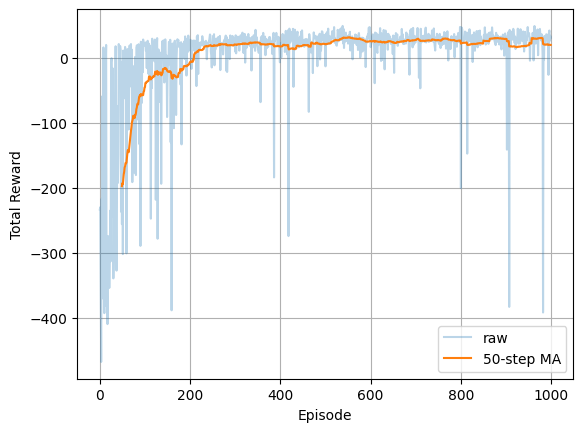

In [3]:
rewards = train_dqn(env, agent, episodes=1000, max_steps=200)
plot_rewards(rewards, window=50)
agent.save("../models/static_auv_dqn.pth")

In [4]:
record_headless(env, agent, out_path='../gifs/static_auv.gif')

Headless recording saved to ../gifs/static_auv.gif


In [ ]:
sr, avg_steps = evaluate_agent(env, agent, episodes=1000, max_steps=200)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [20]:
agent.load("../models/static_auv_dqn.pth")